In [1]:
import quanguru as qg
import numpy as np
import matplotlib.pyplot as plt
import platform

# 17 - Jaynes-Cummings Dynamics

The Jaynes-Cummings Hamiltonian is written as

$H_{JC} = \hbar\omega_{c} a^{\dagger}a + \frac{1}{2}\hbar\omega_{q}\sigma_{z} + \hbar g(a^{\dagger}\sigma_{-} + a\sigma_{+})$

where $\sigma_{\pm} = (\sigma_{x} \pm i\sigma_{y})/2$ are raising/lowering operators for a two-level system, $\sigma_{\mu}$ are the Pauli spin operators with $\mu\in\{x,y,z\}$, $a^{\dagger}$ and $a$ are the creation and annihilation operators for the field mode, and $\omega_{c}$, $\omega_{q}$, and $g$ are the cavity-field, qubit, and coupling (angular-) frequencies, respectively.

We will use the below parameters in our simulation

In [2]:
# parameters for the Hamiltonian
qubitFreq = 1
cavityFreq = 1
couplingFreq = 0.25
cavityDim = 5

# parameters for the evolution
totalTime = 3*(np.pi/couplingFreq)
timeStep = 0.1

and we can describe the JC-Hamiltonian/system in QuanGuru as

In [3]:
# Qubit for the JC model
QubitJC = qg.Qubit(frequency=qubitFreq)

# Cavity for the JC model
CavityJC = qg.Cavity(dimension=cavityDim, frequency=cavityFreq)

# JC model consists of a qubit and cavity
# and this is the 'free evolution' part of the JC-Hamiltonian
JCSystem = QubitJC + CavityJC

The interaction Hamiltonian consists of two terms:
- $a^{\dagger}\sigma_{-}$: cavity creation and qubit lowering 
- $a\sigma_{+}$: cavity annihilation and qubit raising 

When creating multi-system terms ensure the order of the operators is the same as the `QuantumSystem` objects.

e.g. 
```
couplingTerm = totalSystem.createTerm(
    qSystem=[quantumSystem1, quantumSystem2],
    operator=[operator1, operator2])
```
These terms are combined into a single coupling term with frequency (coupling strength) `couplingFreq`. 
If you wish to set individual frequencies for the coupling terms, you can specify them with `frequency` when creating the terms.




In [4]:
# coupling part of the JC-Hamiltonian
# first term of the coupling
JCCouplingT1 = JCSystem.createTerm(
    qSystem=[CavityJC, QubitJC],
    operator=[qg.destroy, qg.sigmap])

# second term of the coupling
JCCouplingT2 = JCSystem.createTerm(
    qSystem=[QubitJC, CavityJC],
    operator=[qg.sigmam, qg.create])

# combine the terms into a single term
JCCoupling = qg.QTerm(qSystem=JCSystem,
                      subSys=[JCCouplingT1, JCCouplingT2],
                      frequency=couplingFreq)

We set the simulation with:
- Simulation parameters defined earlier
- Initial state `[1, 1]`: The first excited state of both cavity and qubit


In [5]:
# set the simulation parameters
JCSystem.simStepSize = timeStep
JCSystem.simTotalTime = totalTime
JCSystem.initialState = [1, 1]


We create a frequency sweep for the cavity to explore the effect of qubit-cavity detuning.

The sweep explores cavity frequencies from $\omega_q - \omega_c$ to $\omega_q + \omega_c$ to observe both on-resonance and off-resonance dynamics.

In [6]:

# create a frequency sweep for the cavity
freqSweep = JCSystem.simulation.Sweep.createSweep(
    system=CavityJC,
    sweepKey="frequency",
    sweepMax=qubitFreq+cavityFreq,
    sweepMin=qubitFreq-cavityFreq,
    sweepStep=.025)

We can create a composite operator in the extended Hilbert space so that measurement can be made without needing to project the state in the compute function.

Here, we create the composite qubit Pauli-Z operator $\langle \sigma_{z} \rangle$ acting on the full qubit $\otimes$ cavity space. 
This gives +1 for $\vert e \rangle$ and -1 for $\vert g \rangle$.

In [7]:
# create sigma Z operator in the extended Hilbert space
# this allows for measuring expectation values without needing to project the state in the compute function.
compositeSZ = qg.compositeOp(qg.sigmaz(),   dimA=cavityDim)

# calculate the desired results and store
def compute(sim, args):
    stateJC = args[0]
    sim.resultsDict['zJC'].append(qg.expectation(compositeSZ, stateJC))

JCSystem.simCompute = compute

<span style="color:red" font-weight="bold"> IMPORTANT NOTE FOR WINDOWS USERS : MULTI-PROCESSING (p=True) DOES NOT WORK WITH NOTEBOOK

You can use a python script, but you will need to make sure that the critical parts of the code are under ``` if __name__ == "__main__": ``` We are going to add further tutorials for this later.

In [8]:
# do not store the states
JCSystem.simDelStates = True

# run the simulation
# p=True uses multi-processing for the sweep
JCSystem.runSimulation(p=(platform.system() != 'Windows'))

Starting sequential sweep with 81 parameter combinations...
Simulation Start:	2025-11-30 14:22:23
[████████████████████████████████████████] 100.0% | Est. Finish: 2025-11-30 14:22:27
Simulation completed in 00h 00m 04s

[]

Text(0, 0.5, 'Time')

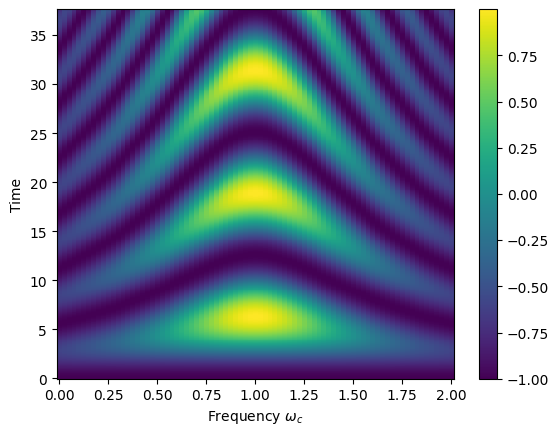

In [9]:
# Plot sigma Z expectation value as a function of time and cavity frequency
Y, X = np.meshgrid(JCSystem.simulation.timeList, freqSweep.sweepList)
plt.pcolormesh(X, Y, JCSystem.simulation.resultsDict['zJC'])
plt.colorbar()
plt.xlabel(r"Frequency $\omega_{c}$")
plt.ylabel("Time")

The plot shows $\langle \sigma_z \rangle$ as a function of time and cavity frequency and we see:
- On resonance ($\Delta \approx 0$): Complete population transfer between qubit and cavity at rate $\sim g$
- Off resonance ($|\Delta| > g$): Partial, faster oscillations at rate $\sim \Delta$
- Chevron pattern: The characteristic shape arises from the detuning-dependent oscillation frequency

The depth of oscillation decreases with increasing detuning, following the relation $\Omega_{Rabi} = \sqrt{g^2 + \Delta^2}$ where $\Delta = \omega_q - \omega_c$.